In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
from BayesGPT.simulators.benchmarks.ddm_ensemble import DDMEnsemble
from BayesGPT.simulators.benchmarks.ssm_ensemble import SSMEnsemble
from BayesGPT.visualization.ensemble_summary import plot_ensemble_summary

In [32]:
ddm_ensemble = DDMEnsemble()

In [33]:
ddm_ensemble.simulators

[{'simulator': <function BayesGPT.simulators.benchmarks.ddm_ensemble.DDMEnsemble._add_variants.<locals>.ddm_basic(drift, boundary)>,
  'simulator_name': 'basic',
  'variable_names': ['drift', 'boundary']},
 {'simulator': <function BayesGPT.simulators.benchmarks.ddm_ensemble.DDMEnsemble._add_variants.<locals>.ddm_with_ndt(drift, boundary, ndt)>,
  'simulator_name': 'with_ndt',
  'variable_names': ['drift', 'boundary', 'ndt']},
 {'simulator': <function BayesGPT.simulators.benchmarks.ddm_ensemble.DDMEnsemble._add_variants.<locals>.ddm_with_trajectory(drift, boundary, ndt)>,
  'simulator_name': 'trajectory',
  'variable_names': ['drift', 'boundary', 'ndt']},
 {'simulator': <function BayesGPT.simulators.benchmarks.ddm_ensemble.DDMEnsemble._add_variants.<locals>.ddm_collapsing_bound(drift, initial_boundary, ndt, collapse_rate)>,
  'simulator_name': 'collapsing_bound',
  'variable_names': ['drift', 'initial_boundary', 'ndt', 'collapse_rate']}]

In [34]:
ddm_params = {
    "drift": 0.5,
    "boundary": 1.0,
    "initial_boundary": 1.0,
    "ndt": 0.3,
    "collapse_rate": 0.01,
}

In [35]:
ddm_results = ddm_ensemble.run(batch_size=10, **ddm_params)

In [36]:
ddm_results.get("trajectory")

[{'RT': 1.31,
  'choice': 1,
  'trajectory': [0,
   0.09973546375310335,
   0.31001258168730605,
   0.30614882963319445,
   0.33604007445404765,
   0.23819892098034073,
   0.3261199195544156,
   0.36240240156669223,
   0.34804141231072566,
   0.28054952568625346,
   0.2858367761688639,
   0.15130956590900238,
   0.15704975976358437,
   0.12102670035009251,
   0.04747520518877392,
   0.3607666549122367,
   0.3698226921231219,
   0.358704690822894,
   0.43693862484164214,
   0.5061914653211125,
   0.40112388889985945,
   0.42499131549966235,
   0.36264103752822713,
   0.42003643508221755,
   0.34506620170917396,
   0.34273819039760384,
   0.37504283580178627,
   0.3136658340743778,
   0.09044444887557654,
   0.20749935193008315,
   0.07628530844967485,
   -0.012451053742622759,
   -0.154075158082899,
   -0.2605109724921584,
   -0.3355532069518763,
   -0.45271426087078553,
   -0.5286453310336704,
   -0.43238859527418005,
   -0.4235500174165014,
   -0.3105374005491399,
   -0.31461285920434

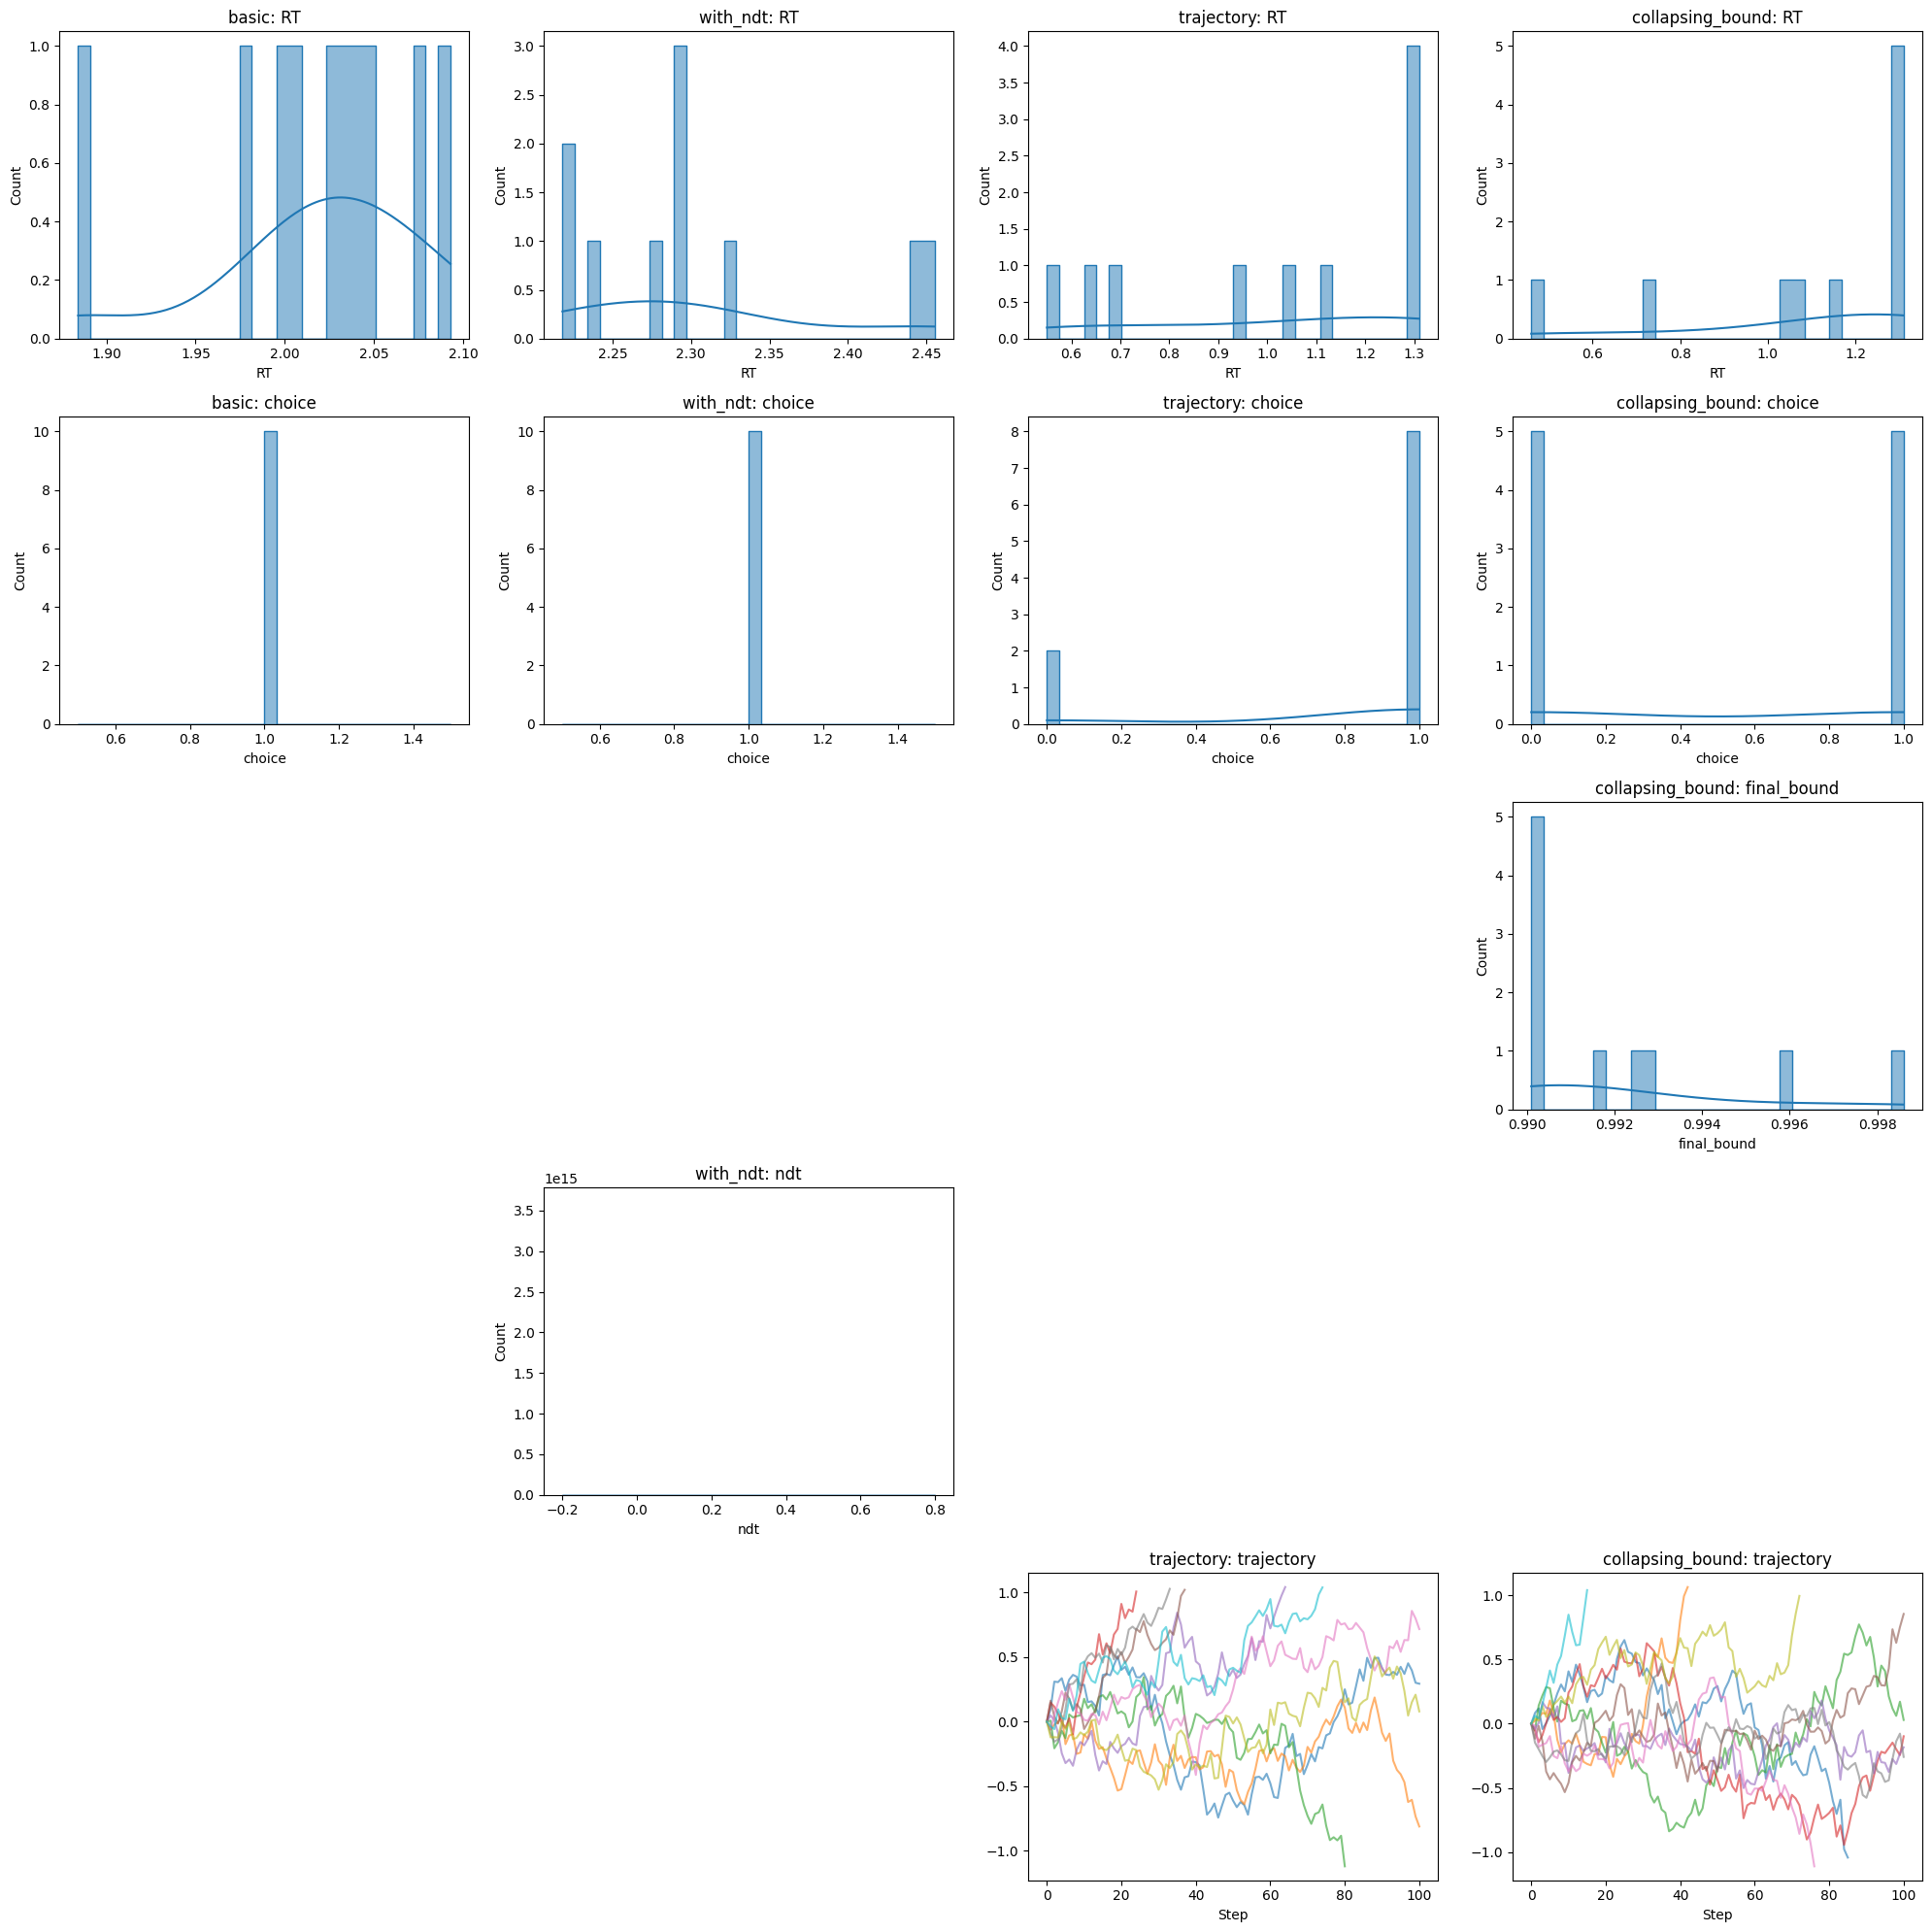

In [38]:
f = plot_ensemble_summary(ddm_results)

In [39]:
ssm_ensemble = SSMEnsemble(models=["ddm", "angle", "weibull"])
ssm_ensemble

In [40]:
ssm_params = {
    "v": 1.0,
    "a": 1.5,
    "z": 0.5,
    "t": 0.3,
    "theta": 0.2,  # Only used by the 'angle' model
    "alpha": 0.5,
    "beta": 0.5,
}

In [41]:
ssm_results = ssm_ensemble.run(batch_size=3, **ssm_params)

In [42]:
ssm_results

{'ddm': [{'RT': array([0.64260286], dtype=float32),
   'choice': array([1], dtype=int32),
   'metadata': {'v': array([1.], dtype=float32),
    'a': array([1.5], dtype=float32),
    'z': array([0.5], dtype=float32),
    't': array([0.3], dtype=float32),
    's': array([1.], dtype=float32),
    'deadline': array([999.], dtype=float32),
    'delta_t': 0.0010000000474974513,
    'max_t': 20.0,
    'n_samples': 1,
    'n_trials': 1,
    'simulator': 'ddm_flexbound',
    'boundary_fun_type': 'constant',
    'possible_choices': [-1, 1],
    'trajectory': array([[ 0.000000e+00],
           [-1.026249e-02],
           [-2.726347e-02],
           ...,
           [-9.990000e+02],
           [-9.990000e+02],
           [-9.990000e+02]], dtype=float32),
    'boundary': array([1.5, 1.5, 1.5, ..., 1.5, 1.5, 1.5], dtype=float32),
    'model': 'ddm'}},
  {'RT': array([1.6277947], dtype=float32),
   'choice': array([1], dtype=int32),
   'metadata': {'v': array([1.], dtype=float32),
    'a': array([1.5],

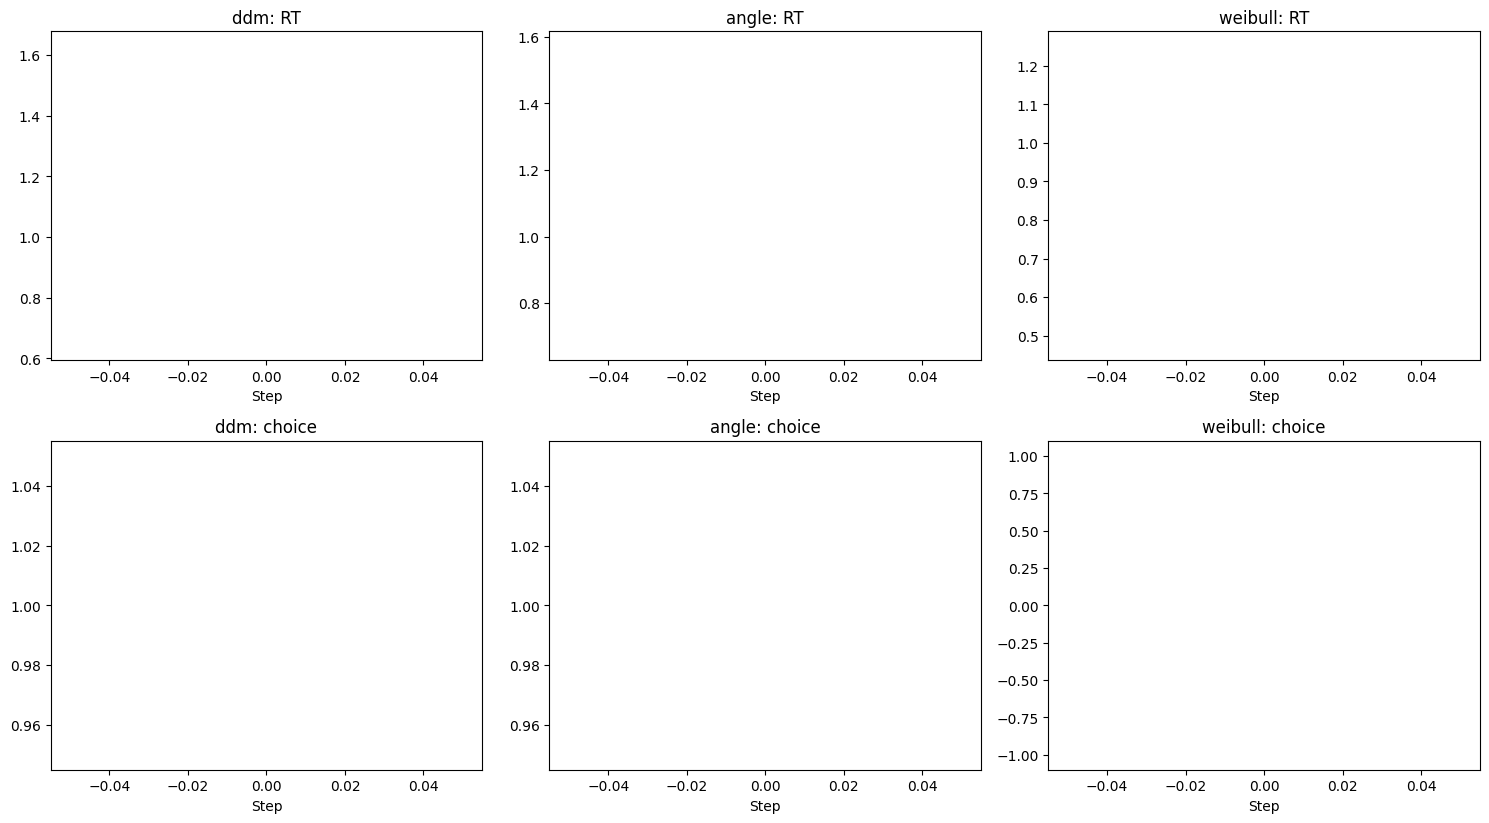

In [43]:
g = plot_ensemble_summary(ssm_results)